In [1]:
import os
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

IMG_SIZE=64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

val_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Scale to [-1, 1]
    ])
aug_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Scale to [-1, 1]
    ])


def get_dataloaders(data_dir, batch_size=24, shuffle=True, transform=val_transform):
    """Larger batch size now that we have memory"""
    # Load the full dataset
    full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
    
    # Filter for only Cats (label 0) and Dogs (label 1) 
    indices = [i for i, (_, label) in enumerate(full_dataset.samples) if label in [0, 1]]
    cat_dog_dataset = Subset(full_dataset, indices)
    
    loader = DataLoader(cat_dog_dataset, batch_size=batch_size, shuffle=shuffle, num_workers=2)
    return loader, full_dataset.classes

def visualize_transformation(model, dataloader, device):
    model.eval()
    
    # 1. Get a batch of real data
    images, labels = next(iter(dataloader))
    images, labels = images.to(device), labels.to(device)
    
    # 2. Pick only the cats (Label 0) from the batch
    cat_indices = (labels == 0).nonzero(as_tuple=True)[0]
    if len(cat_indices) == 0: 
        print("No cats found in this batch to transform.")
        return
    
    # Take top 4 cats
    cats = images[cat_indices[:4]]
    n_samples = len(cats)
    
    # Create the labels we need
    cat_labels = torch.zeros(n_samples, dtype=torch.long).to(device)
    dog_labels = torch.ones(n_samples, dtype=torch.long).to(device) # Target Label
    
    with torch.no_grad():
        # --- STEP A: Pixel -> Latent (Frozen VAE) ---
        # We must compress the real cat images so your model can read them
        posterior = model.pretrained_vae.encode(cats).latent_dist
        cat_latents = posterior.sample() * 0.18215
        
        # --- STEP B: Encode (Your Model) ---
        # Your model takes the compressed cat + cat label -> finds the "content vector" (mu)
        mu, _ = model.encode(cat_latents, cat_labels)
        
        # --- STEP C: Decode (Your Model) ---
        # We assume the content is the same, but we swap the label to "Dog"
        # Your model predicts what the DOG Latents should look like
        transformed_latents = model.decode(mu, dog_labels)
        
        # --- STEP D: Latent -> Pixel (Frozen VAE) ---
        # Unscale and decode to see the final image
        transformed_latents = transformed_latents / 0.18215
        transformed_dogs = model.pretrained_vae.decode(transformed_latents).sample

    # --- Plotting ---
    # Move to CPU for plotting
    cats = cats.cpu()
    transformed_dogs = transformed_dogs.cpu()
    
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    
    # Handle cases where we found fewer than 4 cats
    for i in range(4):
        if i < n_samples:
            # 1. Show Original Cat
            # Denormalize: [-1, 1] -> [0, 1]
            orig_img = (cats[i].permute(1, 2, 0) + 1) / 2
            axes[0, i].imshow(orig_img.clamp(0, 1))
            axes[0, i].set_title("Original Cat")
            axes[0, i].axis('off')
            
            # 2. Show Transformed Dog
            # Denormalize: [-1, 1] -> [0, 1]
            trans_img = (transformed_dogs[i].permute(1, 2, 0) + 1) / 2
            axes[1, i].imshow(trans_img.clamp(0, 1))
            axes[1, i].set_title("Transformed Dog")
            axes[1, i].axis('off')
        else:
            # Hide empty axes if we found fewer than 4 cats
            axes[0, i].axis('off')
            axes[1, i].axis('off')
            
    plt.tight_layout()
    plt.show()


Using device: cuda


In [2]:
import matplotlib.pyplot as plt
import numpy as np

def show_batch(dataloader, classes):
    images, labels = next(iter(dataloader))
    
    # Un-normalize for visualization
    images = images * 0.5 + 0.5 
    
    plt.figure(figsize=(12, 6))
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(np.transpose(images[i].numpy(), (1, 2, 0)))
        plt.title(f"Label: {classes[labels[i]]}")
        plt.axis('off')
    plt.show()

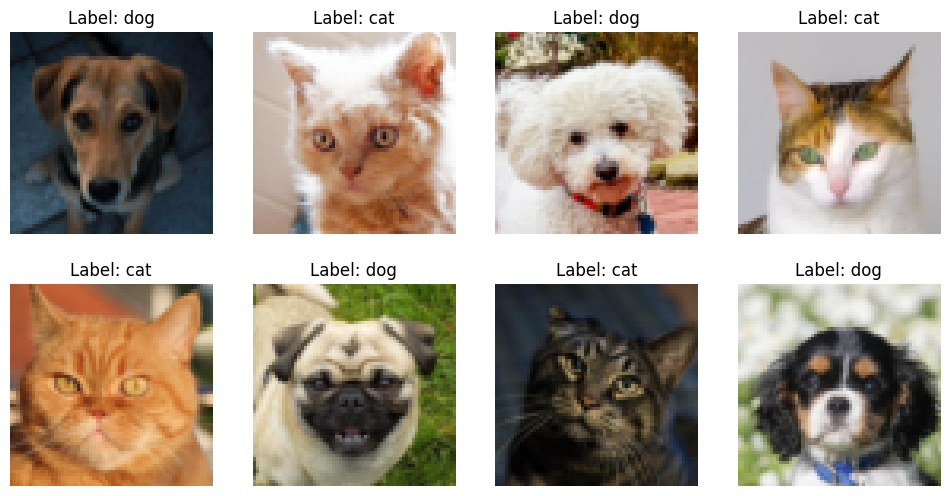

In [3]:
# Setup
train_loader, train_classes = get_dataloaders("./afhq/train")
show_batch(train_loader, train_classes)

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class ConditionalUNet(nn.Module):
    """Competent U-Net for 4GB VRAM - balanced architecture with CLIP conditioning"""
    def __init__(self, c_in=3, c_out=3, time_dim=128, clip_dim=512, device="cuda"):
        super().__init__()
        self.device = device
        self.time_dim = time_dim
        
        # 1. Time Embedding
        self.time_emb = nn.Sequential(
            nn.Linear(1, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )
        
        # 2. CLIP Embedding projection (512 -> time_dim)
        self.clip_proj = nn.Sequential(
            nn.Linear(clip_dim, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )
        self.cond_proj = nn.Linear(time_dim * 2, time_dim)
        
        # 2. Downsampling - 4 levels with strategic attention
        self.inc = DoubleConv(c_in, 64)
        self.down1 = Down(64, 128)
        self.attn1 = AttentionBlock(128)  # Keep this one
        
        self.down2 = Down(128, 256)
        # No attention here (expensive)
        
        self.down3 = Down(256, 256)
        self.attn_mid = AttentionBlock(256)  # Keep bottleneck attention
        
        # 3. Upsampling
        self.up1 = Up(512, 128)
        self.up2 = Up(256, 64)
        self.attn_up = AttentionBlock(64)  # Strategic attention on way up
        self.up3 = Up(128, 64)
        
        self.outc = nn.Conv2d(64, c_out, kernel_size=1)

    def forward(self, x, t, clip_emb):
        t = t.unsqueeze(-1).type(torch.float)
        t_emb = self.time_emb(t)
        
        clip_cond = self.clip_proj(clip_emb)
        
        # Merge time + clip conditioning
        cond = torch.cat([t_emb, clip_cond], dim=1)
        cond = self.cond_proj(cond)

        # Encoder
        x1 = self.inc(x)
        x1 = self.ada_in(x1, cond)
        
        x2 = self.down1(x1)
        x2 = self.ada_in(x2, cond)
        x2 = self.attn1(x2)
        
        x3 = self.down2(x2)
        x3 = self.ada_in(x3, cond)
        
        x4 = self.down3(x3)
        x4 = self.ada_in(x4, cond)
        x4 = self.attn_mid(x4)

        # Decoder
        x = self.up1(x4, x3)
        x = self.ada_in(x, cond)
        
        x = self.up2(x, x2)
        x = self.ada_in(x, cond)
        x = self.attn_up(x)
        
        x = self.up3(x, x1)
        
        return self.outc(x)
    
    def ada_in(self, x, cond):
        """Adaptive Instance Normalization"""
        B, C, H, W = x.shape
        
        mean = x.mean(dim=[2, 3], keepdim=True)
        std = x.std(dim=[2, 3], keepdim=True) + 1e-5
        x = (x - mean) / std
        
        gamma = torch.ones(B, C, 1, 1, device=x.device)
        beta = torch.zeros(B, C, 1, 1, device=x.device)
        
        return gamma * x + beta

# --- Helper Blocks ---
class AttentionBlock(nn.Module):
    """Self-attention block with proper scaling"""
    def __init__(self, channels, num_heads=8):
        super().__init__()
        self.channels = channels
        self.num_heads = num_heads
        self.group_norm = nn.GroupNorm(32, channels)
        
        # Multi-head attention with lower dimension for efficiency
        self.attention = nn.MultiheadAttention(
            channels, 
            num_heads=num_heads, 
            batch_first=True,
            dropout=0.1
        )
        self.proj_out = nn.Linear(channels, channels)
        
    def forward(self, x):
        B, C, H, W = x.shape
        h = self.group_norm(x)
        
        # Reshape for attention: (B, C, H, W) -> (B, H*W, C)
        h = h.permute(0, 2, 3, 1).reshape(B, H*W, C)
        
        # Self-attention
        attn_out, _ = self.attention(h, h, h)
        attn_out = self.proj_out(attn_out)
        
        # Reshape back: (B, H*W, C) -> (B, C, H, W)
        attn_out = attn_out.reshape(B, H, W, C).permute(0, 3, 1, 2)
        
        return x + 0.1 * attn_out  # Light residual connection

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), 
            nn.GroupNorm(32, out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), 
            nn.GroupNorm(32, out_ch), 
            nn.GELU(),
        )
    def forward(self, x): 
        return self.conv(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.mpconv = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_ch, out_ch))
    def forward(self, x): 
        return self.mpconv(x)

class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class Diffusion:
    def __init__(self, noise_steps=1000, img_size=64, device="cuda", schedule="cosine"):
        self.noise_steps = noise_steps
        self.img_size = img_size
        self.device = device
        
        if schedule == "cosine":
            self.beta = self.cosine_beta_schedule(noise_steps).to(device)
        else:
            self.beta = torch.linspace(1e-4, 0.02, noise_steps).to(device)
        
        self.alpha = 1. - self.beta
        self.alpha_hat = torch.cumprod(self.alpha, dim=0)

    def cosine_beta_schedule(self, timesteps, s=0.008):
        """Cosine schedule"""
        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)

    def noise_images(self, x, t):
        sqrt_alpha_hat = torch.sqrt(self.alpha_hat[t])[:, None, None, None]
        sqrt_one_minus_alpha_hat = torch.sqrt(1 - self.alpha_hat[t])[:, None, None, None]
        epsilon = torch.randn_like(x)
        return sqrt_alpha_hat * x + sqrt_one_minus_alpha_hat * epsilon, epsilon

    def sample_timesteps(self, n):
        return torch.randint(low=1, high=self.noise_steps, size=(n,)).to(self.device)

    def img2img(self, model, image, target_label, clip_embeddings, start_step=500):
        """Translate image with CLIP conditioning"""
        model.eval()
        n = image.shape[0]
        
        t_start = torch.full((n,), start_step, device=self.device, dtype=torch.long)
        x, _ = self.noise_images(image, t_start)
        
        target_clip_emb = clip_embeddings[target_label].unsqueeze(0).expand(n, -1)
        
        with torch.no_grad():
            for i in reversed(range(1, start_step)):
                t = torch.ones(n) * i
                t = t.long().to(self.device)
                
                predicted_noise = model(x, t, target_clip_emb)
                
                alpha = self.alpha[t][:, None, None, None]
                alpha_hat = self.alpha_hat[t][:, None, None, None]
                beta = self.beta[t][:, None, None, None]
                
                noise = torch.randn_like(x) if i > 1 else torch.zeros_like(x)
                
                x = (1 / torch.sqrt(alpha)) * (x - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise) + torch.sqrt(beta) * noise
        
        return (x.clamp(-1, 1) + 1) / 2


In [5]:
# Load CLIP text encoder
from transformers import CLIPTextModel, CLIPTokenizer

print("Loading CLIP text encoder...")
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
clip_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_encoder.eval()
for param in clip_encoder.parameters():
    param.requires_grad = False

# Pre-compute CLIP embeddings for cat and dog
with torch.no_grad():
    cat_tokens = tokenizer(["a cat"], padding=True, return_tensors="pt").to(device)
    cat_embed = clip_encoder(**cat_tokens).pooler_output  # (1, 512)
    
    dog_tokens = tokenizer(["a dog"], padding=True, return_tensors="pt").to(device)
    dog_embed = clip_encoder(**dog_tokens).pooler_output  # (1, 512)

clip_embeddings = {0: cat_embed.squeeze(0), 1: dog_embed.squeeze(0)}
print(f"CLIP embedding shape: {clip_embeddings[0].shape}")
print("✓ CLIP loaded and ready")

/home/teo/kaggle/csiro/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading CLIP text encoder...
CLIP embedding shape: torch.Size([512])
✓ CLIP loaded and ready


# Training util functions

In [6]:
def train_epoch(model, dataloader, optimizer, device, epoch, num_epochs, img_size=128, clip_embeddings=None):
    model.train()
    train_loss = 0
    
    # Instantiate the Diffusion helper
    diffusion = Diffusion(img_size=img_size, device=device, schedule="cosine")
    mse = nn.MSELoss()
    
    for batch_idx, (data, labels) in enumerate(dataloader):
        data, labels = data.to(device), labels.to(device)

        optimizer.zero_grad()
        
        # --- Get CLIP embeddings for batch ---
        clip_cond = torch.stack([clip_embeddings[int(l)] for l in labels]).to(device)
        
        # --- Diffusion Training Steps ---
        t = diffusion.sample_timesteps(data.shape[0])
        x_t, noise = diffusion.noise_images(data, t)
        
        predicted_noise = model(x_t, t, clip_cond)
        
        loss = mse(noise, predicted_noise)
        
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
    avg_loss = train_loss / len(dataloader)
    return avg_loss

def validate_epoch(model, dataloader, device, img_size=128, clip_embeddings=None):
    model.eval()
    val_loss = 0
    
    diffusion = Diffusion(img_size=img_size, device=device, schedule="cosine")
    mse = nn.MSELoss()
    
    with torch.no_grad():
        for data, labels in dataloader:
            data, labels = data.to(device), labels.to(device)
            
            # --- Get CLIP embeddings for batch ---
            clip_cond = torch.stack([clip_embeddings[int(l)] for l in labels]).to(device)
            
            t = diffusion.sample_timesteps(data.shape[0])
            x_t, noise = diffusion.noise_images(data, t)
            
            predicted_noise = model(x_t, t, clip_cond)
            
            loss = mse(noise, predicted_noise)
            val_loss += loss.item()
            
    avg_loss = val_loss / len(dataloader)
    return avg_loss


# Training Loop

In [8]:
from copy import deepcopy

train_loader, train_classes = get_dataloaders("./afhq/train", batch_size=12, transform=aug_transform)
val_loader, val_classes = get_dataloaders("./afhq/val", batch_size=12, shuffle=False)

# --- Configuration ---
num_epochs = 500  # Train longer now
learning_rate = 1e-4
img_size = IMG_SIZE

# Initialize Model - now competent with selective attention
model = ConditionalUNet(device=device).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model Parameters: {total_params:,} | Trainable: {trainable_params:,}")
print(f"Architecture: 4-level U-Net with selective attention + proper AdaIN conditioning")

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=num_epochs, eta_min=1e-7
)

best_val_loss = np.inf
patience = 40
patience_counter = 0

# --- Main Loop ---
for epoch in range(1, num_epochs + 1):
    # Training
    train_loss = train_epoch(model, train_loader, optimizer, device, epoch, num_epochs, img_size=img_size, clip_embeddings=clip_embeddings)
    
    # Validation
    val_loss = validate_epoch(model, val_loader, device, img_size=img_size, clip_embeddings=clip_embeddings)
    
    print(f'Epoch {epoch}/{num_epochs}: Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}')
    
    scheduler.step()
    
    # Early stopping + checkpointing
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        print(f"  ✓ Saved best model (val_loss: {val_loss:.6f})")
        state_dict = deepcopy(model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch} epochs")
            break


Model Parameters: 3,927,363 | Trainable: 3,927,363
Architecture: 4-level U-Net with selective attention + proper AdaIN conditioning
Epoch 1/500: Train Loss: 0.132573 | Val Loss: 0.075787
  ✓ Saved best model (val_loss: 0.075787)
Epoch 2/500: Train Loss: 0.067557 | Val Loss: 0.061553
  ✓ Saved best model (val_loss: 0.061553)
Epoch 3/500: Train Loss: 0.058726 | Val Loss: 0.057141
  ✓ Saved best model (val_loss: 0.057141)
Epoch 4/500: Train Loss: 0.056117 | Val Loss: 0.049685
  ✓ Saved best model (val_loss: 0.049685)
Epoch 5/500: Train Loss: 0.053335 | Val Loss: 0.050438
Epoch 6/500: Train Loss: 0.052006 | Val Loss: 0.058037
Epoch 7/500: Train Loss: 0.050276 | Val Loss: 0.050435
Epoch 8/500: Train Loss: 0.049900 | Val Loss: 0.046555
  ✓ Saved best model (val_loss: 0.046555)
Epoch 9/500: Train Loss: 0.048147 | Val Loss: 0.051256
Epoch 10/500: Train Loss: 0.047319 | Val Loss: 0.052173
Epoch 11/500: Train Loss: 0.047084 | Val Loss: 0.050468
Epoch 12/500: Train Loss: 0.047495 | Val Loss: 0.04

KeyboardInterrupt: 

In [18]:
model.load_state_dict(state_dict)

<All keys matched successfully>

# Visualize trained model output

In [19]:
import torch
import matplotlib.pyplot as plt

def translate_species(model, diffusion, image, source_label, clip_embeddings, strength=0.6):
    """
    Translates an image from one species to another (Cat <-> Dog).
    
    Args:
        model: The trained ConditionalUNet.
        diffusion: The Diffusion instance.
        image: A single image tensor of shape (3, 64, 64).
        source_label: The integer label of the input image (0 or 1).
        clip_embeddings: Dict with CLIP embeddings {0: cat_embed, 1: dog_embed}
        strength (float): How much to change the image (0.0 to 1.0).
                          0.4 = Retains structure, changes texture.
                          0.8 = Changes shape completely, loose match to pose.
    """
    model.eval()
    
    # 1. Setup Data
    x = image.unsqueeze(0).to(model.device) 
    
    # Get target CLIP embedding (toggle: cat->dog or dog->cat)
    target_label_int = 1 - source_label
    target_clip_emb = clip_embeddings[target_label_int].unsqueeze(0).to(model.device)
    
    # 2. Determine Noise Level (t)
    start_step = int(diffusion.noise_steps * strength)
    t_start = torch.full((1,), start_step, device=model.device, dtype=torch.long)
    
    # 3. Forward Process (add noise)
    noisy_image, _ = diffusion.noise_images(x, t_start)
    x_gen = noisy_image
    
    # 4. Reverse Process (denoise with target CLIP embedding)
    with torch.no_grad():
        for i in reversed(range(1, start_step)):
            t = torch.ones(1).long().to(model.device) * i
            
            predicted_noise = model(x_gen, t, target_clip_emb)
            
            alpha = diffusion.alpha[t][:, None, None, None]
            alpha_hat = diffusion.alpha_hat[t][:, None, None, None]
            beta = diffusion.beta[t][:, None, None, None]
            
            noise = torch.randn_like(x_gen) if i > 1 else torch.zeros_like(x_gen)
            
            x_gen = (1 / torch.sqrt(alpha)) * (
                x_gen - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise
            ) + torch.sqrt(beta) * noise

    # 5. Return processed image
    return (x_gen.clamp(-1, 1) + 1) / 2

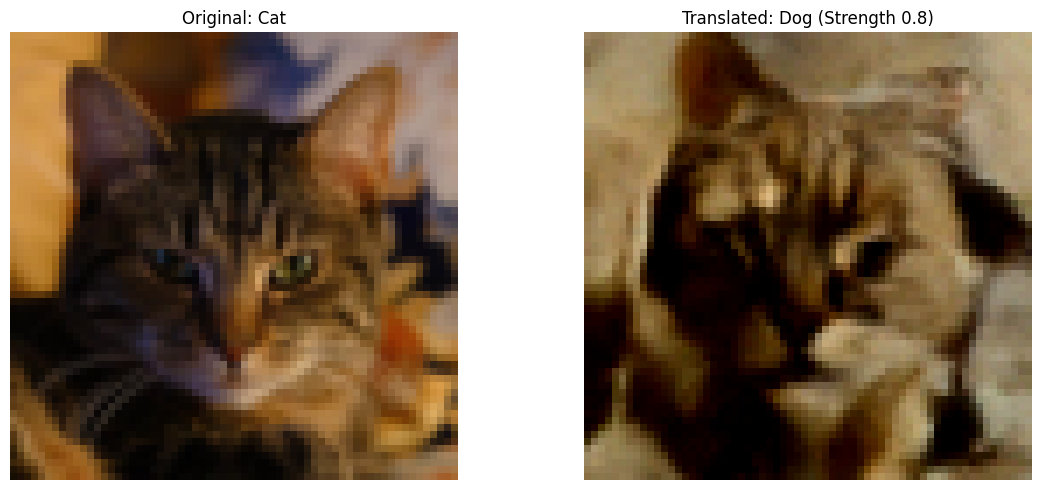

In [25]:
# --- Configuration ---
STRENGTH = 0.8  # Lower strength keeps more structure

# Get a real image from validation set
real_img, label = val_loader.dataset[1]

# Translate with CORRECT image size
diffusion_tools = Diffusion(img_size=IMG_SIZE, device=device, schedule="cosine")
model.load_state_dict(state_dict)
translated_img = translate_species(
    model, 
    diffusion_tools, 
    real_img, 
    label, 
    clip_embeddings,
    strength=STRENGTH
)

# --- Visualization ---
real_img_show = (real_img.permute(1, 2, 0) + 1) / 2
trans_img_show = translated_img.squeeze().cpu().permute(1, 2, 0)

class_names = ['Cat', 'Dog']

plt.figure(figsize=(12, 5))

# Original
plt.subplot(1, 2, 1)
plt.title(f"Original: {class_names[label]}")
plt.imshow(real_img_show.clamp(0, 1))
plt.axis('off')

# Translated
plt.subplot(1, 2, 2)
plt.title(f"Translated: {class_names[1-label]} (Strength {STRENGTH})")
plt.imshow(trans_img_show.clamp(0, 1))
plt.axis('off')

plt.tight_layout()
plt.show()


Attempting to generate 4 Cats from scratch...


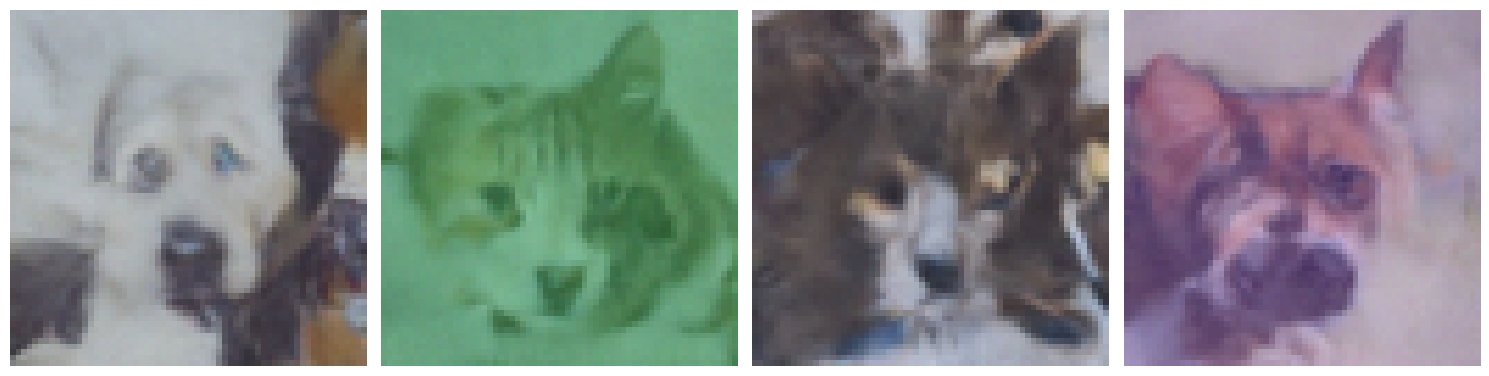

In [24]:
import matplotlib.pyplot as plt

def generate_from_scratch(model, diffusion, class_label=0, clip_embeddings=None, n_images=4):
    """
    Generates images from pure noise (Step 1000 -> 0).
    """
    model.eval()
    with torch.no_grad():
        # 1. Start from Pure Random Noise
        x = torch.randn((n_images, 3, diffusion.img_size, diffusion.img_size)).to(device)
        
        # Get CLIP embedding for target class
        target_clip_emb = clip_embeddings[class_label].unsqueeze(0).expand(n_images, -1).to(device)
        
        # 2. Denoise loop (Full 1000 steps)
        for i in reversed(range(1, diffusion.noise_steps)):
            t = torch.ones(n_images).long().to(device) * i
            predicted_noise = model(x, t, target_clip_emb)
            
            alpha = diffusion.alpha[t][:, None, None, None]
            alpha_hat = diffusion.alpha_hat[t][:, None, None, None]
            beta = diffusion.beta[t][:, None, None, None]
            
            if i > 1:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)
                
            x = (1 / torch.sqrt(alpha)) * (x - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise) + torch.sqrt(beta) * noise
            x = torch.clamp(x, -1.0, 1.0)
    
    # 3. Un-normalize from [-1, 1] to [0, 1]
    x = (x.clamp(-1, 1) + 1) / 2
    return x

# --- RUN DIAGNOSTIC ---
diff_debug = Diffusion(img_size=IMG_SIZE, device=device, schedule="cosine")

# Generate 4 Cats
print("Attempting to generate 4 Cats from scratch...")
gen_imgs = generate_from_scratch(model, diff_debug, class_label=1, clip_embeddings=clip_embeddings, n_images=4)

plt.figure(figsize=(15, 5))
for i in range(len(gen_imgs)):
    plt.subplot(1, 4, i+1)
    
    img = gen_imgs[i].detach().cpu()
    img = img.permute(1, 2, 0)
    
    plt.imshow(img.clamp(0, 1))
    plt.axis('off')
    
plt.tight_layout()
plt.show()
